In [22]:
from pipe import Pipe
from datetime import datetime

import timestamps_and_frames
import features
import dataframes
import paths
import times


@Pipe
def log(stream, label, every=10):
    start = datetime.now()
    for count, item in enumerate(stream):
        if count == 0:
            print(f"[{datetime.now()}] {label}: first item")
        elif count % every == 0:
            elapsed = datetime.now() - start
            print(f"[{datetime.now()}] {label}: {count} items ({elapsed})")
        yield item
    elapsed = datetime.now() - start
    print(f"[{datetime.now()}] {label}: done — {count + 1} items ({elapsed})")


def dataframe_from_hive_number(hive_number):
    hive_name = paths.hive_name_from_number(hive_number)
    return dataframes.dataframe_from_hourly_stream(
        hive_number
        | paths.hive_audio_folderpath_from_hive_number
        | timestamps_and_frames.hourly_audio_from_hive_folderpath
        | log("hourly audio")
        | features.hourly_features_from_audio_stream
        | log("hourly features"),
        hive_name=hive_name,
    )

In [2]:
skip = {"timestamp", "hive", "time_slice"}
feature_columns = [
    c for c in dataframe.columns
    if c not in skip
    and not c.startswith("agg_")
]
agg_columns = [c for c in dataframe.columns if c.startswith("agg_")]

print(f"{len(feature_columns)} feature columns, {len(agg_columns)} aggregation columns")
print(f"date range: {dataframe['timestamp'].min()} → {dataframe['timestamp'].max()}")
print(f"time slices: {dataframe['time_slice'].unique()}")

41 feature columns, 82 aggregation columns
date range: 2026-03-07 17:03:14.500000 → 2026-03-21 16:36:10.750000
time slices: ['15-18' '18-21' '21-00' '00-03' '03-06' '06-09' '09-12' '12-15']


/tmp/nix-shell.Z5ONxU/ipykernel_1841990/3792887221.py:21: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  axis.plot_date(dates, dataframe[name].values, fmt="-", linewidth=0.3, alpha=0.6)


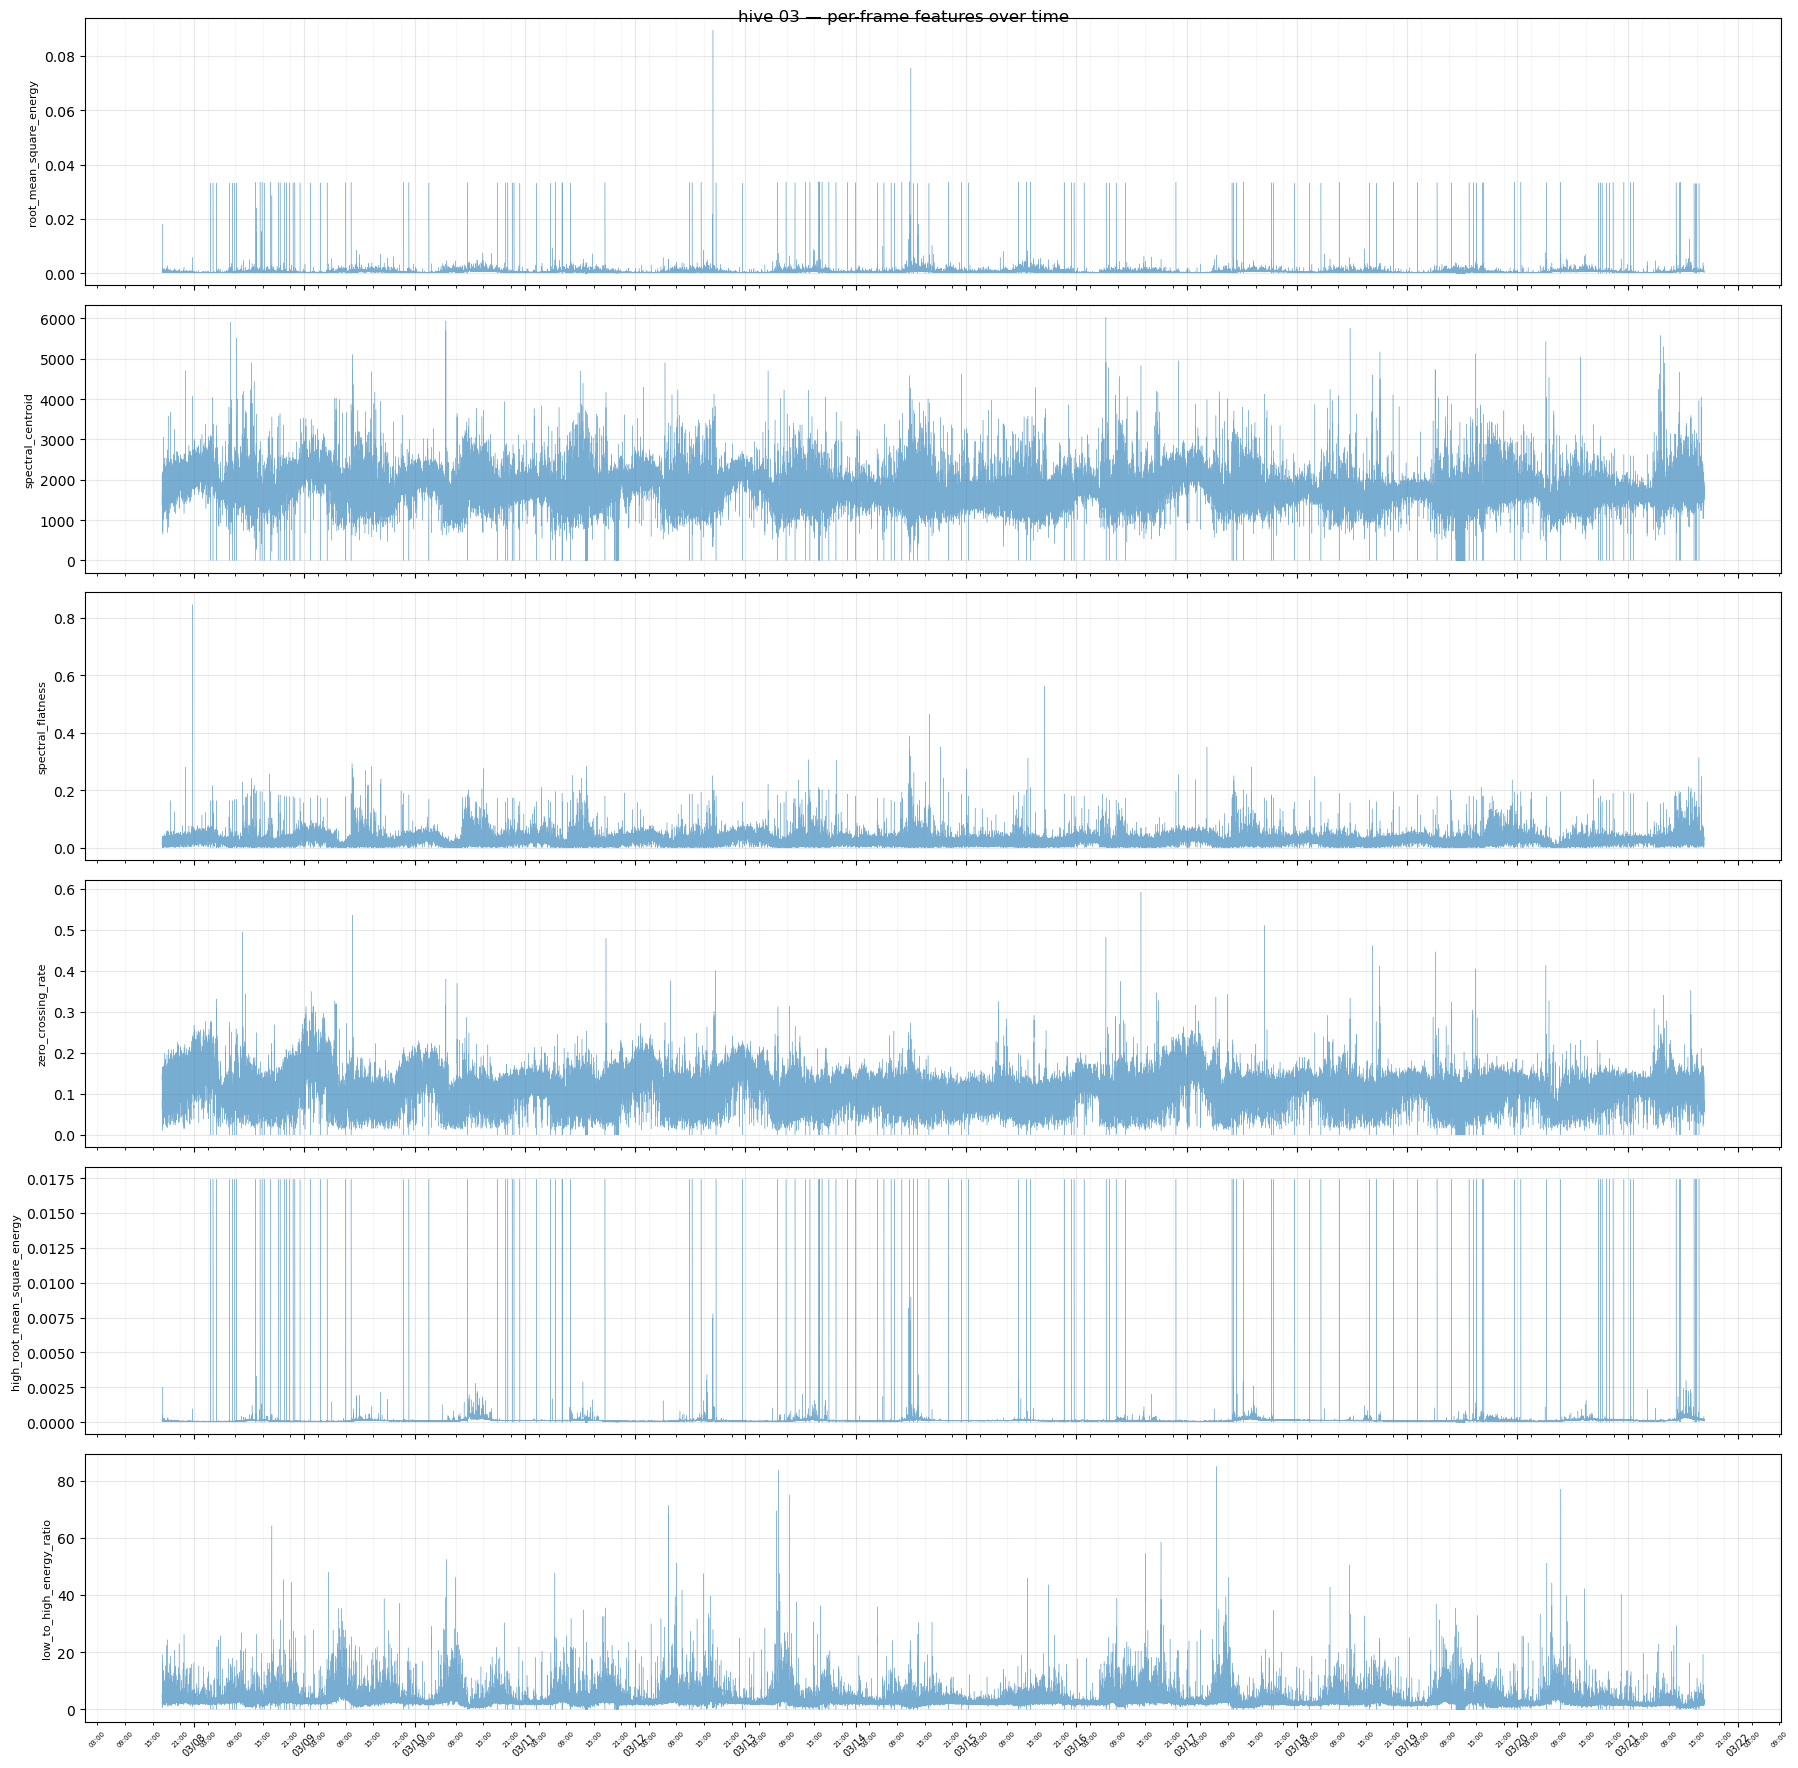

In [5]:
# quick overview: a few key features over time
plot_features = [
    "root_mean_square_energy",
    "spectral_centroid",
    "spectral_flatness",
    "zero_crossing_rate",
    "high_root_mean_square_energy",
    "low_to_high_energy_ratio",
]
existing = [f for f in plot_features if f in dataframe.columns]

figure, axes = matplotlib.pyplot.subplots(
    len(existing), 1,
    figsize=(18, 3 * len(existing)),
    sharex=True,
)

dates = matplotlib.dates.date2num(dataframe["timestamp"])

for axis, name in zip(axes, existing):
    axis.plot_date(dates, dataframe[name].values, fmt="-", linewidth=0.3, alpha=0.6)
    axis.set_ylabel(name, fontsize=8)
    axis.xaxis.set_major_locator(matplotlib.dates.DayLocator())
    axis.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%m/%d"))
    axis.xaxis.set_minor_locator(matplotlib.dates.HourLocator(interval=6))
    axis.xaxis.set_minor_formatter(matplotlib.dates.DateFormatter("%H:%M"))
    axis.tick_params(axis="x", which="minor", labelsize=5, rotation=45)
    axis.tick_params(axis="x", which="major", labelsize=7, rotation=45)
    axis.grid(which="major", alpha=0.3)
    axis.grid(which="minor", alpha=0.1)

figure.suptitle("hive 03 — per-frame features over time")
figure.tight_layout()
matplotlib.pyplot.show()

/tmp/nix-shell.Z5ONxU/ipykernel_1841990/1727198066.py:13: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  axis.plot_date(dates, zoomed[name].values, fmt="-", linewidth=0.5)


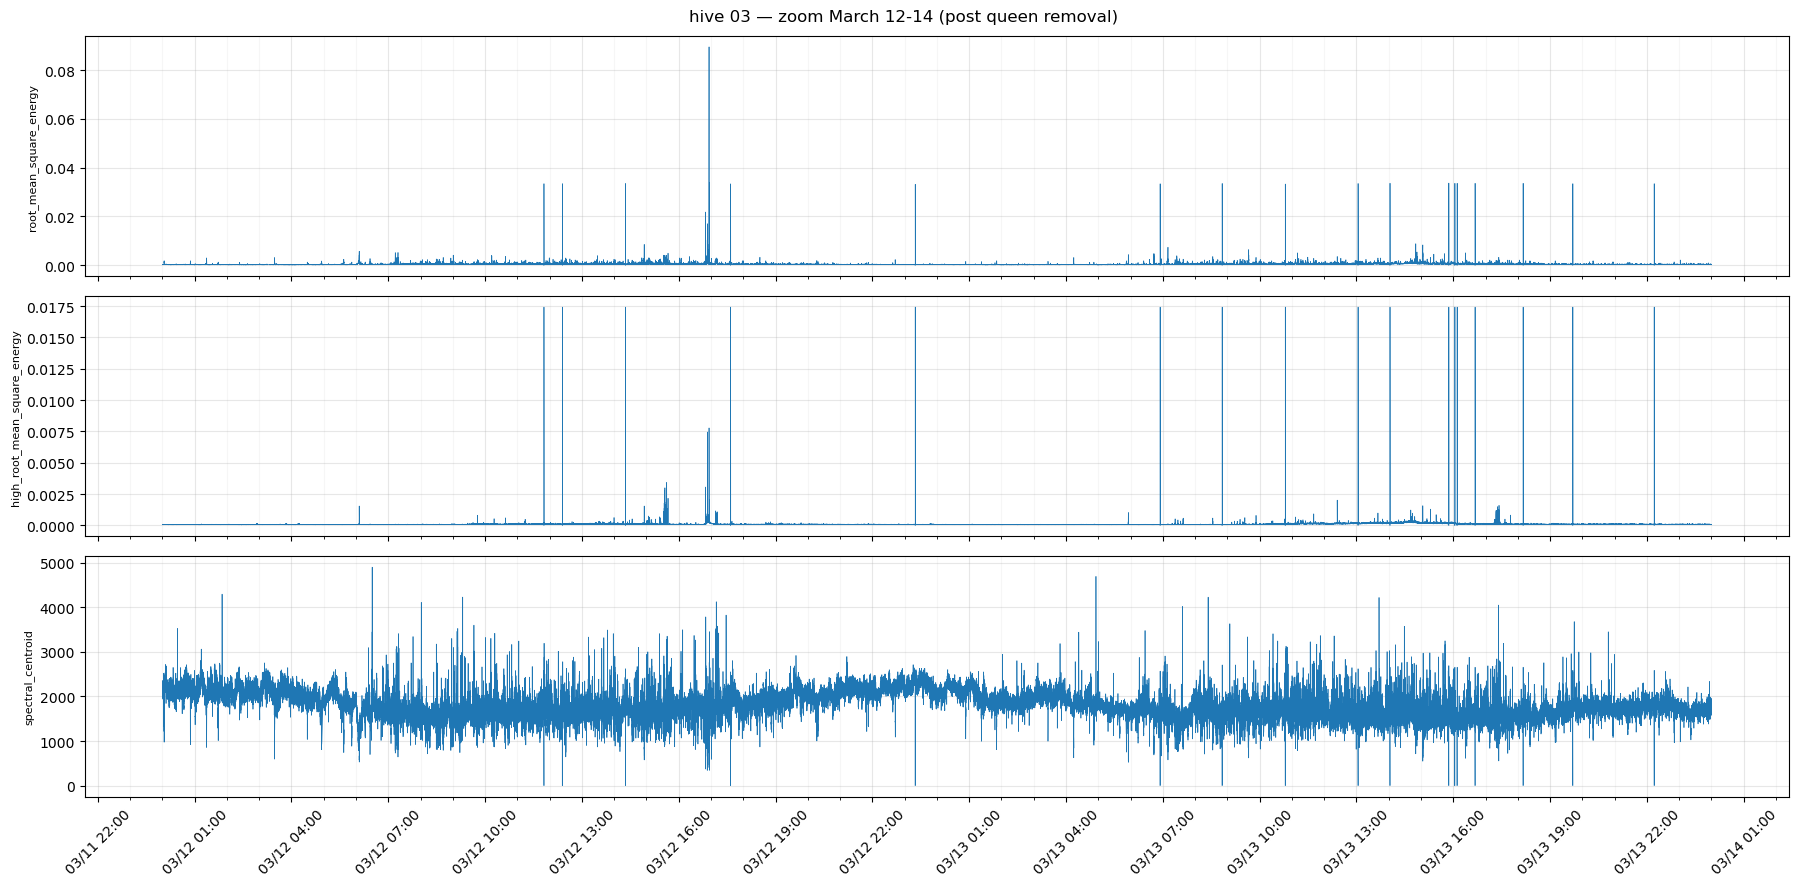

In [8]:
import matplotlib.dates

mask = (
    (dataframe["timestamp"] >= "2026-03-12")
    & (dataframe["timestamp"] <= "2026-03-14")
)
zoomed = dataframe[mask]
dates = matplotlib.dates.date2num(zoomed["timestamp"])

figure, axes = matplotlib.pyplot.subplots(3, 1, figsize=(18, 9), sharex=True)

for axis, name in zip(axes, ["root_mean_square_energy", "high_root_mean_square_energy", "spectral_centroid"]):
    axis.plot_date(dates, zoomed[name].values, fmt="-", linewidth=0.5)
    axis.set_ylabel(name, fontsize=8)
    axis.xaxis.set_major_locator(matplotlib.dates.HourLocator(interval=3))
    axis.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%m/%d %H:%M"))
    axis.xaxis.set_minor_locator(matplotlib.dates.HourLocator())
    axis.grid(which="major", alpha=0.3)
    axis.grid(which="minor", alpha=0.1)

axes[-1].tick_params(axis="x", rotation=45)
figure.suptitle("hive 03 — zoom March 12-14 (post queen removal)")
figure.tight_layout()
matplotlib.pyplot.show()

/tmp/nix-shell.Z5ONxU/ipykernel_1841990/262681456.py:16: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  axis.plot_date(dates, zoomed[name].values, fmt="-", linewidth=0.8)


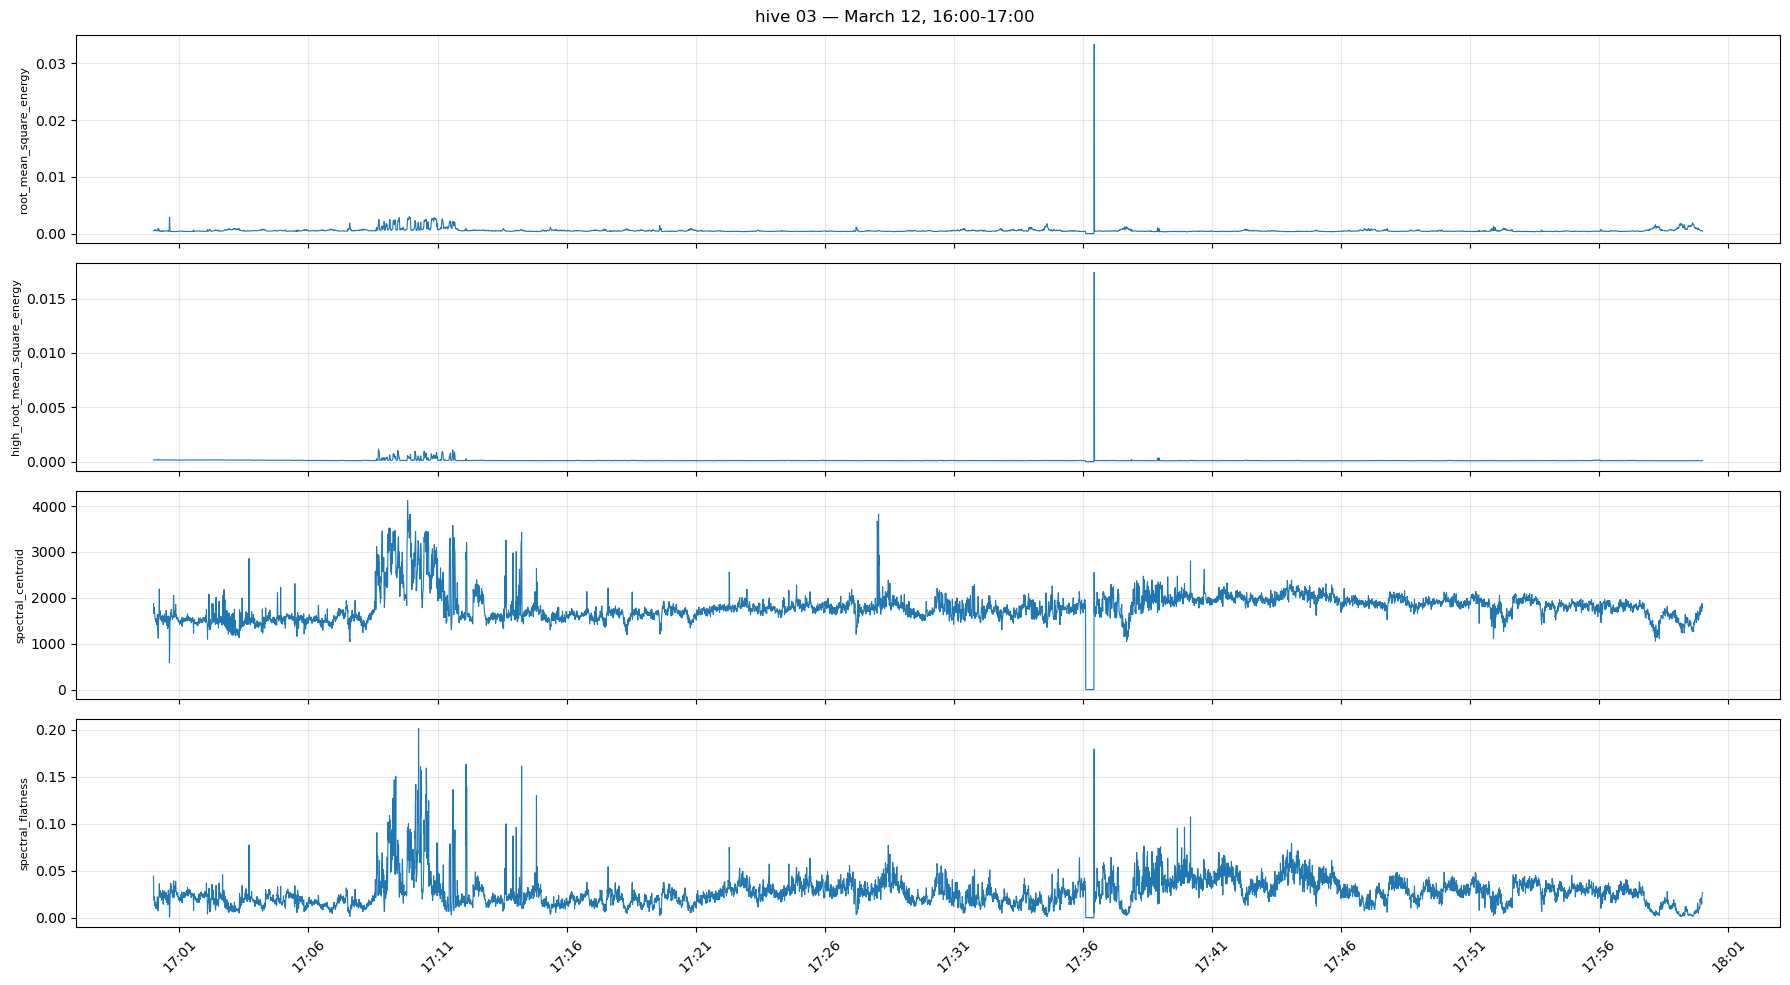

In [11]:
mask = (
    (dataframe["timestamp"] >= "2026-03-12 17:00")
    & (dataframe["timestamp"] <= "2026-03-12 18:00")
)
zoomed = dataframe[mask]
dates = matplotlib.dates.date2num(zoomed["timestamp"])

figure, axes = matplotlib.pyplot.subplots(4, 1, figsize=(18, 10), sharex=True)

for axis, name in zip(axes, [
    "root_mean_square_energy",
    "high_root_mean_square_energy",
    "spectral_centroid",
    "spectral_flatness",
]):
    axis.plot_date(dates, zoomed[name].values, fmt="-", linewidth=0.8)
    axis.set_ylabel(name, fontsize=8)
    axis.xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=5))
    axis.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H:%M"))
    axis.grid(alpha=0.3)

axes[-1].tick_params(axis="x", rotation=45)
figure.suptitle("hive 03 — March 12, 16:00-17:00")
figure.tight_layout()
matplotlib.pyplot.show()

/tmp/nix-shell.Z5ONxU/ipykernel_1841990/2566525966.py:15: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  axis.plot_date(dates, zoomed[name].values, fmt="o-", markersize=2, linewidth=0.8)


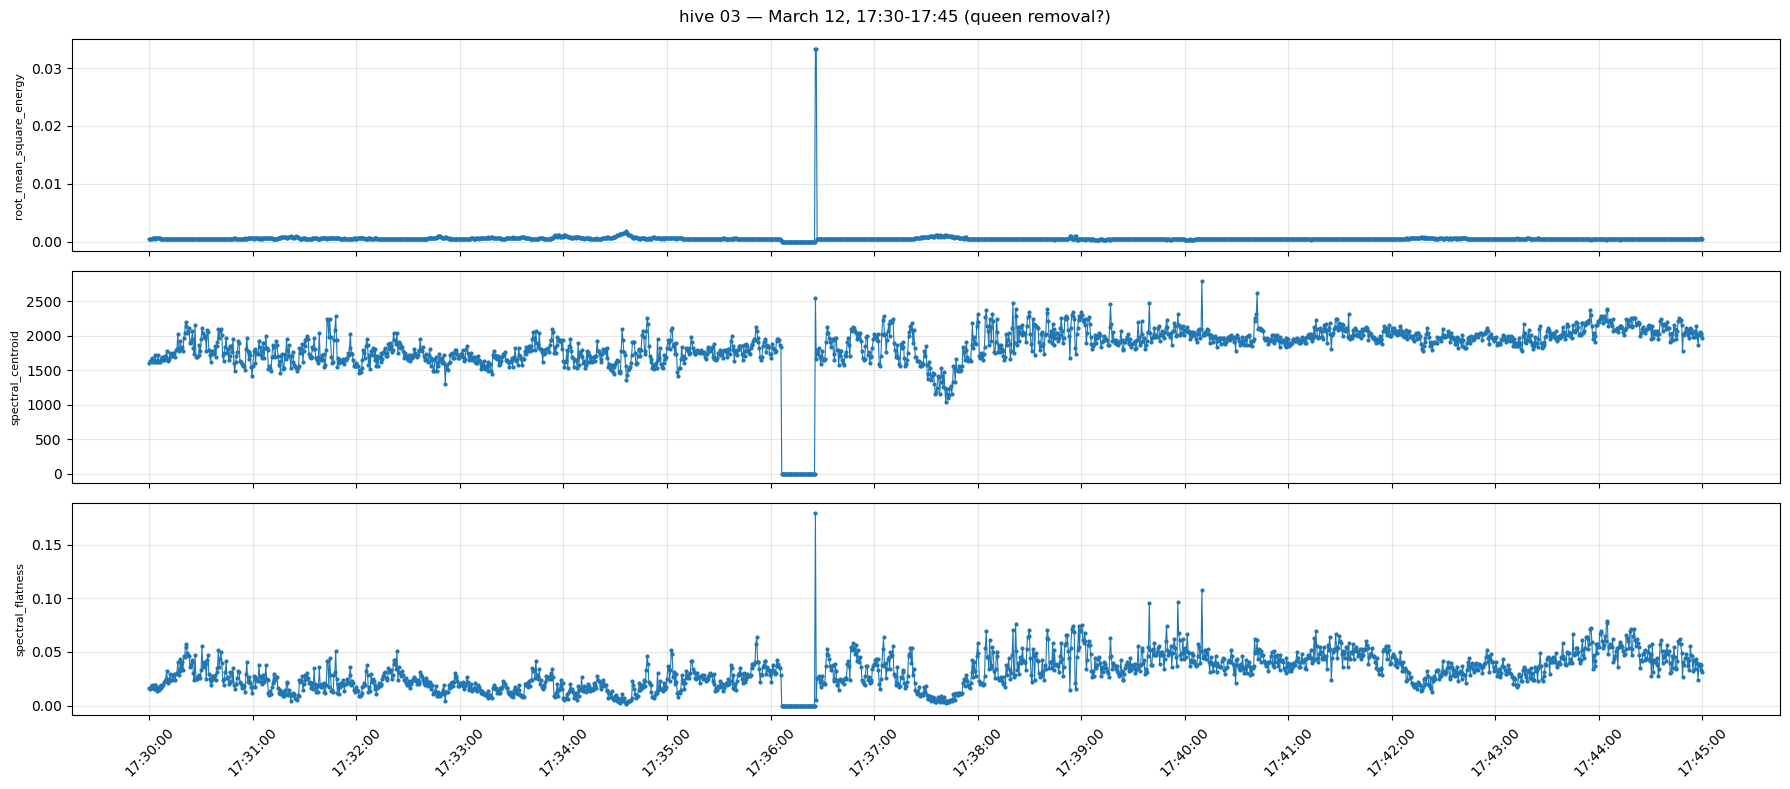

In [12]:
mask = (
    (dataframe["timestamp"] >= "2026-03-12 17:30")
    & (dataframe["timestamp"] <= "2026-03-12 17:45")
)
zoomed = dataframe[mask]
dates = matplotlib.dates.date2num(zoomed["timestamp"])

figure, axes = matplotlib.pyplot.subplots(3, 1, figsize=(18, 8), sharex=True)

for axis, name in zip(axes, [
    "root_mean_square_energy",
    "spectral_centroid",
    "spectral_flatness",
]):
    axis.plot_date(dates, zoomed[name].values, fmt="o-", markersize=2, linewidth=0.8)
    axis.set_ylabel(name, fontsize=8)
    axis.xaxis.set_major_locator(matplotlib.dates.MinuteLocator())
    axis.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H:%M:%S"))
    axis.grid(alpha=0.3)

axes[-1].tick_params(axis="x", rotation=45)
figure.suptitle("hive 03 — March 12, 17:30-17:45 (queen removal?)")
figure.tight_layout()
matplotlib.pyplot.show()

In [20]:
import soundfile
import paths
from pipe import where, select

flac_files = list(
    3
    | paths.hive_audio_folderpath_from_hive_number
    | Pipe(paths.sorted_filepaths_from_folderpath)
    | where(lambda fp: fp.endswith(".flac"))
    | select(lambda fp: (fp, *paths.metadata_from_filepath(fp)))
)

for i in range(min(10, len(flac_files) - 1)):
    filepath_a, _, ts_a = flac_files[i]
    filepath_b, _, ts_b = flac_files[i + 1]

    info_a = soundfile.info(filepath_a)
    duration_a = info_a.duration

    from datetime import datetime
    start_a = datetime.strptime(ts_a, "%Y%m%d_%H%M%S")
    start_b = datetime.strptime(ts_b, "%Y%m%d_%H%M%S")

    gap_seconds = (start_b - start_a).total_seconds() - duration_a
    print(f"{ts_a} | duration={duration_a:.1f}s | gap to next={gap_seconds:+.1f}s")

20260307_170314 | duration=1800.0s | gap to next=+0.0s
20260307_173314 | duration=1800.0s | gap to next=+0.0s
20260307_180314 | duration=1800.0s | gap to next=+0.0s
20260307_183314 | duration=1800.0s | gap to next=+0.0s
20260307_190314 | duration=1800.0s | gap to next=+0.0s
20260307_193314 | duration=1800.0s | gap to next=+0.0s
20260307_200314 | duration=1800.0s | gap to next=+0.0s
20260307_203314 | duration=1800.0s | gap to next=+0.0s
20260307_210314 | duration=1800.0s | gap to next=+0.0s
20260307_213314 | duration=1800.0s | gap to next=+0.0s


In [17]:
import paths
from pipe import where
from pipe import Pipe

flac_files = list(
    3
    | paths.hive_audio_folderpath_from_hive_number
    | Pipe(paths.sorted_filepaths_from_folderpath)
    | where(lambda fp: "20260312_17" in fp)
)
for fp in flac_files:
    print(paths.metadata_from_filepath(fp))

('hive_03', '20260312_172506')
('hive_03', '20260312_175526')


In [2]:
@Pipe
def append_empty_features(stream):
    for timestamp, frame in stream:
        yield timestamp, frame, {}

@Pipe
def discard_frames(stream):
    for timestamp, frame, features in stream:
        yield timestamp, features

@Pipe
def append_empty_tags(stream):
    for timestamp, features in stream:
        yield timestamp, features, {}

@Pipe
def put_hive_tag(stream, hive_name):
    for timestamp, features, tags in stream:
        yield timestamp, features, {**tags, "hive": hive_name}

@Pipe
def append_empty_aggregations(stream):
    for timestamp, features, tags in stream:
        yield timestamp, features, tags, {}

In [3]:
import numpy
def dataframe_from_stream(tuples, hive_name):
    rows = []
    for timestamp, features, tags, aggregations in tuples:
        flat_features = flattened_from_feature_dict(features)
        rows.append({
            "timestamp": timestamp,
            "hive": tags["hive"],
            "time_slice": tags["time_slice"],
            **flat_features,
            **{f"agg_{k}": v for k, v in aggregations.items()},
        })
    return pandas.DataFrame(rows)

def flattened_from_feature_dict(features):
    flat = {}
    for key, value in features.items():
        if isinstance(value, numpy.ndarray):
            for i, v in enumerate(value):
                flat[f"{key}_{i}"] = float(v)
        else:
            flat[key] = value
    return flat

def feature_columns_from_dataframe(dataframe):
    skip = {"timestamp", "hive", "time_slice"}
    return [
        c for c in dataframe.columns
        if c not in skip
        and not c.startswith("agg_")
        and not isinstance(dataframe[c].iloc[0], numpy.ndarray)
    ]
import os

def saved_csv_filepath_from_dataframe(
    dataframe,
    dataframe_filename,
    save_index=True,
):
    if not os.path.exists(paths.features_folderpath):
        print(f"\ncreating data_folder: {fpaths.eatures_folderpath}")
        os.makedirs(paths.features_folderpath)
    file_path = os.path.join(paths.features_folderpath, dataframe_filename)
    dataframe.to_csv(file_path, index=save_index)
    return file_path


In [4]:
from pipe import Pipe
from datetime import datetime

@Pipe
def log(stream, label, every=1000):
    start = datetime.now()
    for count, item in enumerate(stream):
        if count == 0:
            print(f"[{datetime.now()}] {label}: first item")
        elif count % every == 0:
            elapsed = datetime.now() - start
            print(f"[{datetime.now()}] {label}: {count} items ({elapsed})")
        yield item
    elapsed = datetime.now() - start
    print(f"[{datetime.now()}] {label}: done — {count + 1} items ({elapsed})")

In [ ]:
import numpy
import matplotlib.pyplot
from pipe import take

import timestamps_and_frames
import features
import paths
import times

feature_names = [
    "high_root_mean_square_energy",
    "low_root_mean_square_energy",
    "spectral_centroid",
    "spectral_flux",
]

stream = (
    4
    | paths.hive_audio_folderpath_from_hive_number
    | timestamps_and_frames.from_hive_folderpath(
        date_range=("2026-03-09", "2026-03-11"),
        hour_range=("10:00", "15:00"),
    )
    | append_empty_features
    | features.put_all_features
    | features.put_spectral_flux
    | take(5000)
    | sink(list)
)

timestamps = numpy.array([t for t, _, _ in stream])
feature_dicts = [f for _, _, f in stream]

figure, axes = matplotlib.pyplot.subplots(len(feature_names), 1, figsize=(18, 3 * len(feature_names)), sharex=True)
for axis, name in zip(axes, feature_names):
    values = numpy.array([d[name] for d in feature_dicts])
    axis.plot(range(len(values)), values, linewidth=0.5)
    axis.set_ylabel(name, fontsize=8)

axes[-1].set_xlabel("frame index")
figure.suptitle("hive 04 — per-frame features — March 9-11, 10:00-15:00 (post queen removal)")
figure.tight_layout()
matplotlib.pyplot.show()

In [5]:
import normalization
import pandas
import timestamps_and_frames
import features
import passbands
import paths
import times
import aggregations

def dataframe_from_hive_number(hive_number):
    tuples = (
        hive_number
        | paths.hive_audio_folderpath_from_hive_number
        | timestamps_and_frames.from_hive_folderpath
        | log("framing", every=500)
        | append_empty_features
        | features.put_unwindowed_features
        | features.put_all_features
        | log("features", every=500)
        | take(10000)
        | discard_frames
        | append_empty_tags
        | put_hive_tag(hive_name=paths.hive_name_from_number(hive_number))
        | times.put_time_slice_tag
        | append_empty_aggregations
        | aggregations.put_slice_aggregations
        | log("aggregations", every=100)
        | sink(list)
    )
    features_dataframe = dataframe_from_stream(
        tuples,
        hive_name=f'hive_{hive_number:02d}'
    )
    return features_dataframe

ModuleNotFoundError: No module named 'normalization'

In [ ]:
raise

In [ ]:
dataframe_from_hive_number(4)

In [ ]:
import timestamps_and_frames
import features
import paths
import times
import aggregations
import dataframes

def saved_features_filepath_from_hive_number(hive_number):
    tuples = (
        hive_number
        | paths.hive_audio_folderpath_from_hive_number
        | timestamps_and_frames.from_hive_folderpath
        | log("framing", every=500)
        | append_empty_features
        | features.put_all_features
        | log("features", every=500)
        | discard_frames
        | append_empty_tags
        | put_hive_tag(hive_name=paths.hive_name_from_number(hive_number))
        | times.put_time_slice_tag
        | append_empty_aggregations
        | aggregations.put_slice_aggregations
        | log("aggregations", every=100)
        | sink(list)
    )
    features_dataframe = dataframes.dataframe_from_stream(
        tuples,
        hive_name=paths.hive_name_from_number(hive_number),
    )
    return dataframes.saved_csv_filepath_from_dataframe(
        dataframe=features_dataframe,
        dataframe_filename=f"hive_{hive_number:02d}_features",
    )


In [ ]:
import normalization
import pandas
import timestamps_and_frames
import features
import passbands
import paths
import times
import aggregations

tuples = (
    paths.hive_audio_folderpath_from_hive_number(2)
    | timestamps_and_frames.from_hive_folderpath        
    | append_empty_features
    | features.put_unwindowed_features
    | features.put_all_features
    | discard_frames
    | append_empty_tags
    | put_hive_tag(hive_name='whatver')
    | times.put_time_slice_tag
    | append_empty_aggregations
    | aggregations.put_slice_aggregations
    | sink(list)
) 
test_dataframe = normalization.dataframe_from_stream(tuples, hive_name='hiiive')

In [ ]:
test_dataframe

In [ ]:
import os
def saved_dataframe_path_from_dataframe(data_frame, data_folder_path, data_frame_file_name, save_index=True):
    if not os.path.exists(data_folder_path):
        print(f"\ncreating data_folder: {data_folder_path}")
        os.makedirs(data_folder_path)
    file_path = os.path.join(data_folder_path, data_frame_file_name)
    data_frame.to_csv(file_path, index=save_index)
    return file_path

In [ ]:
saved_data_frame_path_from_data_frame(
    test_dataframe,
    paths.data_folderpath + 'features/',
    "hive_02"
)

In [ ]:
zscored_dataframe = normalization.zscored_dataframe_from_dataframe(test_dataframe)


In [ ]:
zscored_dataframe

In [ ]:
raise

In [ ]:
# Cell 1 — collect frame-level features per hive
import pandas
import timestamps_and_frames
import features
import passbands
import paths
import times
import aggregations
from pipe import take

(
    paths.audio_hive_02_folderpath
    | timestamps_and_frames.from_hive_folderpath(
        date_range=times.queen_event_month_window,
    )
    | append_empty_features
    | features.put_unwindowed_features
    | features.put_windowed_features
    | features.put_passband_features(passbands.low_and_middle_and_high)
    | features.put_modulation_features(
        passbands.low_and_middle_and_high,
        batch_size=120,
    )
    | take(1)
    | discard_frames
    | append_empty_tags
    | put_hive_tag(hive_name='whatver')
    | times.put_time_slice_tag
    | sink(list)
)

In [ ]:
import timestamps_and_frames
import features
import passbands
import paths
import times
import aggregations
from pipe import take, tail

(
    paths.audio_hive_02_folderpath
    | timestamps_and_frames.from_hive_folderpath(
        date_range=times.queen_event_month_window,
    )
    | append_empty_features
        | features.put_all_features
    | take(300)
    | discard_frames
    | append_empty_tags
    | put_hive_tag(hive_name="hive_02")
    | times.put_time_slice_tag
    | append_empty_aggregations
    | aggregations.put_slice_aggregations
    | tail(1)
    | sink(identity)
)

In [ ]:
# Cell 1 — collect frame-level features per hive
import pandas
import timestamps_and_frames
import features
import passbands
import paths
import times
import aggregations
from pipe import take

def frame_features_from_hive(folderpath, hive_name):
    pairs = list(
        folderpath
        | timestamps_and_frames.from_hive_folderpath(
            date_range=times.queen_event_month_window,
        )
        | append_empty_features
        | features.put_all_features
        | take(10)
        | without_frames
        | sink(list)
        | aggregations.dataframe_from_timestamp_features_pairs(hive_name=hive_name)
    )
    return 

hives = [
    (paths.audio_hive_02_folderpath, "hive_02"),
    (paths.audio_hive_03_folderpath, "hive_03"),
    (paths.audio_hive_04_folderpath, "hive_04"),
]

frame_dataframe = pandas.concat(
    [frame_features_from_hive(fp, name) for fp, name in hives],
    ignore_index=True,
)

In [ ]:
frame_dataframe

In [ ]:
import plot
import frames
import paths
import matplotlib

(
    paths.audio_hive_02_folderpath
    | Pipe(frames.from_hive_folderpath)
    | select(only_frame(lambda x: x))
    | take(5)
    | chain
    | sink(matplotlib.pyplot.plot)
)



In [ ]:
import plot
import frames
import paths
import numpy
(
    paths.audio_hive_02_folderpath
    | timestamps_and_frames.from_hive_folderpath
    | take(200)
    | sink(plot.spectrogram)
)


In [ ]:
import plot
import frames
import paths
import numpy
import times
(

    paths.audio_hive_04_folderpath
    | timestamps_and_frames.from_hive_folderpath(
        date_range=times.queen_event_month_window, 
        hour_range=times.daytime
    )
    | take(200)
    | sink(plot.spectrogram)
)
